# Aula 4 — EDA Profissional (Versão Avançada) - Para Aula
**Dataset:** Airbnb NYC

## Objetivos Desta Aula
- **Explorar um dataset real de mercado:** Entender a estrutura e o conteúdo de dados reais.
- **Detectar e tratar valores faltantes e outliers:** Aprender técnicas para limpar e preparar os dados.
- **Realizar análise por categoria e por localização:** Investigar padrões e tendências em diferentes segmentos e regiões.
- **Construir gráficos profissionais e informativos:** Utilizar bibliotecas avançadas para visualizações de alta qualidade.
- **Introduzir correlação entre variáveis:** Entender as relações entre diferentes atributos do dataset.
- **Engenharia de Features:** Criar novas variáveis para enriquecer a análise.
- **Análise Geoespacial:** Visualizar dados em um contexto geográfico.
- **Interpretar e comunicar insights:** Extrair conclusões significativas dos dados.


## 1) Importação das bibliotecas Essenciais
Nesta seção, importamos todas as bibliotecas Python necessárias para a Análise Exploratória de Dados (EDA).

- `pandas`: Para manipulação e análise de dados em formato de DataFrame.
- `matplotlib.pyplot`: Para a criação de gráficos estáticos.
- `seaborn`: Baseado no matplotlib, oferece uma interface de alto nível para criar gráficos estatísticos atraentes e informativos.
- `numpy`: Para operações numéricas e matemáticas, especialmente útil para lidar com arrays e cálculos estatísticos.
- `folium`: Para criar mapas interativos e visualizar dados geoespaciais.


In [1]:
# Importe aqui as bibliotecas necessárias: pandas, matplotlib.pyplot, seaborn, numpy, folium
# Configure os estilos de visualização (sns.set_style, plt.rcParams)
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import folium
from folium.plugins import MarkerCluster

## 2) Carregar o Dataset
Carregamos o dataset do Airbnb NYC a partir de um arquivo CSV. Este é o primeiro passo para qualquer análise de dados, onde os dados brutos são lidos e transformados em um DataFrame do pandas para fácil manipulação.


In [2]:
# Carregue o arquivo CSV "AB_NYC_2019.csv" em um DataFrame do pandas
# Exiba as primeiras linhas do DataFrame para uma visão inicial dos dados
df = pd.read_csv("../AB_NYC_2019.csv")

## 3) Visão Geral e Estrutura dos Dados
Esta seção fornece uma visão geral rápida do dataset, incluindo suas dimensões, tipos de dados e um resumo estatístico. Isso nos ajuda a entender a estrutura dos dados e identificar possíveis problemas, como valores ausentes ou tipos de dados incorretos.


In [3]:
# Exiba o número de linhas e colunas do DataFrame (df.shape)
# Exiba informações sobre o DataFrame, incluindo tipos de dados e valores não-nulos (df.info())
# Exiba estatísticas descritivas para as colunas numéricas (df.describe())
# Exiba estatísticas descritivas para todas as colunas (incluindo categóricas) (df.describe(include="all"))
linhas, colunas = df.shape
print("Número de linhas: ", linhas)
print("Número de colunas: ", colunas)
print("\n")
print(df.info())
print(df.describe())
print(df.describe(include="all"))

Número de linhas:  48895
Número de colunas:  16


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64 

## 4) Tratamento de Valores Faltantes
Valores faltantes são comuns em datasets reais e podem afetar a qualidade da análise. Nesta seção, identificamos e tratamos esses valores, decidindo entre remover, preencher com um valor específico (média, mediana, moda) ou usar métodos mais avançados.


In [4]:
# Calcule e exiba a quantidade de valores faltantes por coluna
print("Antes das alteracoes: ")
print(df.isnull().sum())

# Preencha os valores faltantes nas colunas `name` e `host_name` com "unknown"
df["name"] = df["name"].fillna("unknown")
df["host_name"] = df["host_name"].fillna("unknown")

# Preencha os valores faltantes na coluna `reviews_per_month` com 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Converta a coluna `last_review` para datetime e preencha os valores faltantes com uma data de referência (e.g., "2010-01-01")
df["last_review"] = pd.to_datetime(df["last_review"])
df["last_review"] = df["last_review"].fillna(pd.Timestamp("2010-01-01"))

# Verifique novamente os valores faltantes após o tratamento
print("\nDepois das alteracoes: ")
print(df.isnull().sum())


Antes das alteracoes: 
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Depois das alteracoes: 
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type  

## 5) Detecção e Tratamento de Outliers
Outliers são pontos de dados que se desviam significativamente de outras observações. Eles podem distorcer análises estatísticas e modelos de machine learning. Nesta seção, identificamos e tratamos outliers em variáveis numéricas chave, como `price` e `minimum_nights`. Usaremos o método do Intervalo Interquartil (IQR) para uma abordagem robusta.


In [5]:
# Defina uma função `remove_outliers_iqr` para detectar e remover outliers usando o método IQR
def remove_outliers_iqr(df, coluna):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    new_df = df[(df[coluna] < limite_superior) & (df[coluna] > limite_inferior)]
    return new_df


# Aplique a função para tratar outliers nas colunas `price`, `minimum_nights` e `number_of_reviews`
new_df = remove_outliers_iqr(df, "price")
new_df = remove_outliers_iqr(new_df, "minimum_nights")
new_df = remove_outliers_iqr(new_df, "number_of_reviews")


# Exiba as estatísticas descritivas antes e depois do tratamento para cada coluna
print("Antes do tratamento")
print(df[["price", "minimum_nights", "number_of_reviews"]].describe())


print("\nDepois do tratamento")
print(new_df[["price", "minimum_nights", "number_of_reviews"]].describe())



# Atualize o DataFrame principal com os dados limpos
df = new_df.copy()





Antes do tratamento
              price  minimum_nights  number_of_reviews
count  48895.000000    48895.000000       48895.000000
mean     152.720687        7.029962          23.274466
std      240.154170       20.510550          44.550582
min        0.000000        1.000000           0.000000
25%       69.000000        1.000000           1.000000
50%      106.000000        3.000000           5.000000
75%      175.000000        5.000000          24.000000
max    10000.000000     1250.000000         629.000000

Depois do tratamento
              price  minimum_nights  number_of_reviews
count  35103.000000    35103.000000       35103.000000
mean     119.322366        2.758824          12.250377
std       67.845778        1.904313          16.446665
min        0.000000        1.000000           0.000000
25%       65.000000        1.000000           1.000000
50%      100.000000        2.000000           5.000000
75%      155.000000        3.000000          17.000000
max      333.000000    

## 6) Análise Exploratória de Dados (EDA) Aprofundada
Com os dados limpos, podemos agora aprofundar nossa análise, explorando as distribuições das variáveis, as relações entre elas e identificando padrões que podem gerar insights valiosos.


### 6.1) Distribuição de Preços
Vamos visualizar a distribuição dos preços dos aluguéis para entender a faixa de valores e identificar a concentração de preços.


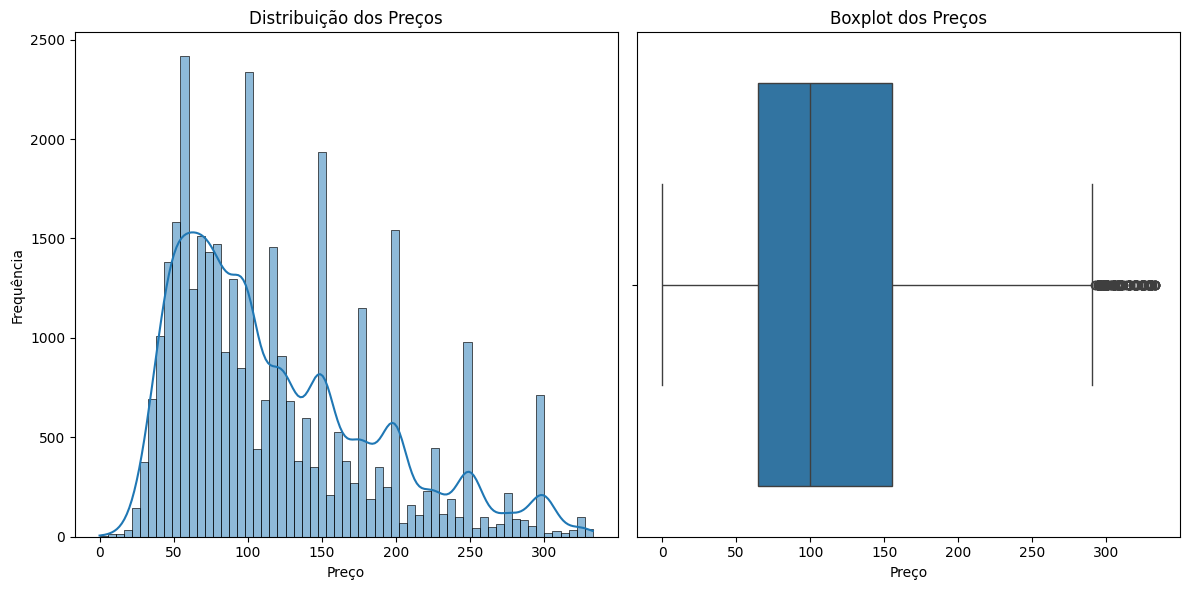

In [6]:
plt.figure(figsize=(12, 6))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(x=df["price"], kde=True)
plt.title("Distribuição dos Preços")
plt.xlabel("Preço")
plt.ylabel("Frequência")


# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df["price"])
plt.title("Boxplot dos Preços")
plt.xlabel("Preço")

plt.tight_layout()  
plt.show()

### 6.2) Análise por Tipo de Quarto (`room_type`)
Entender a distribuição dos tipos de quartos e como eles se relacionam com o preço é crucial para proprietários e hóspedes.


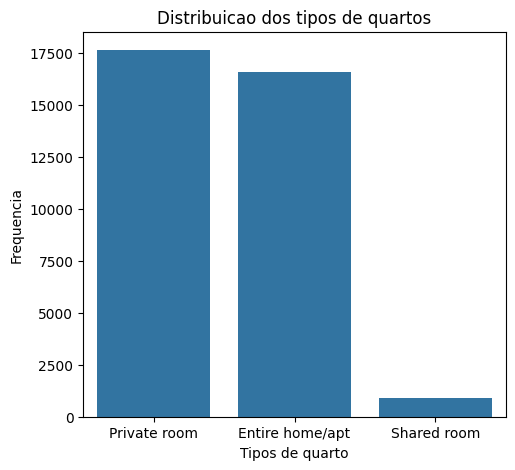

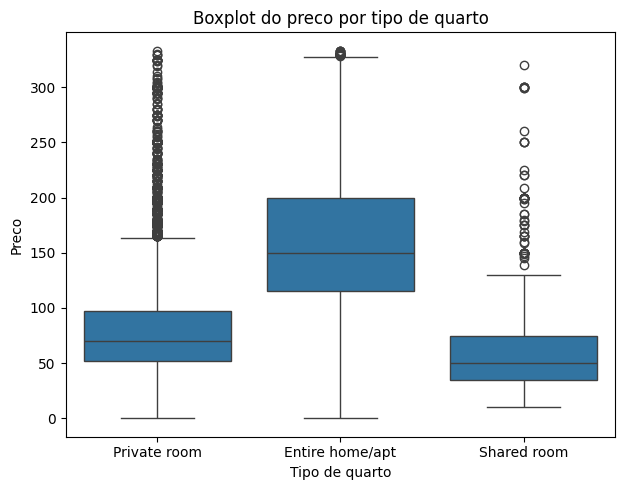

In [7]:
# Crie um gráfico de contagem dos tipos de quarto usando `sns.countplot`
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.title("Distribuicao dos tipos de quartos")
plt.ylabel("Frequencia")
plt.xlabel("Tipos de quarto")
sns.countplot(x=df["room_type"])
plt.show()

# Crie um boxplot do preço por tipo de quarto usando `sns.boxplot`
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.title("Boxplot do preco por tipo de quarto")
plt.xlabel("Tipo de quarto")
plt.ylabel("Preco")
sns.boxplot(x=df["room_type"], y=df["price"])
plt.tight_layout()
plt.show()
# Adicione títulos e rótulos aos gráficos

### 6.3) Análise por Grupo de Bairro (`neighbourhood_group`)
A localização é um dos fatores mais importantes no mercado imobiliário. Vamos analisar como os preços e a disponibilidade variam entre os diferentes grupos de bairros de NYC.


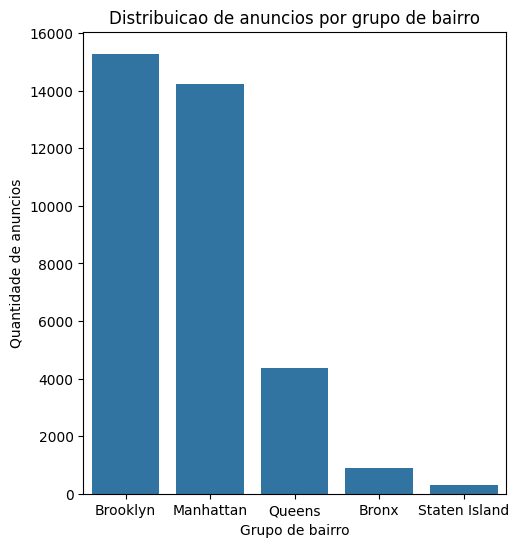

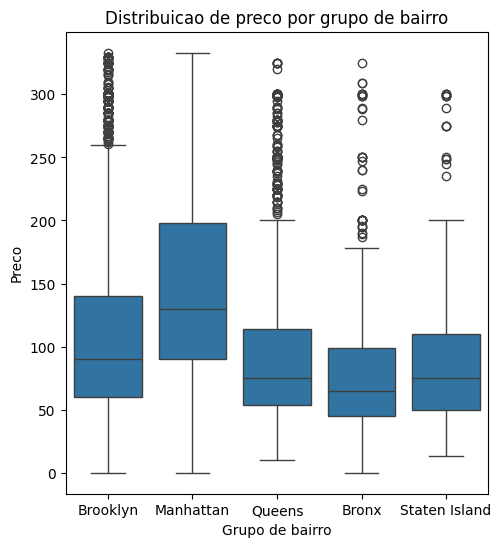

In [8]:
# Crie um gráfico de contagem de anúncios por grupo de bairro usando `sns.countplot`
# Crie um boxplot do preço por grupo de bairro usando `sns.boxplot`
# Adicione títulos e rótulos aos gráficos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Distribuicao de anuncios por grupo de bairro")
plt.xlabel("Grupo de bairro")
plt.ylabel("Quantidade de anuncios")
sns.countplot(x=df["neighbourhood_group"])
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.title("Distribuicao de preco por grupo de bairro")
plt.xlabel("Grupo de bairro")
plt.ylabel("Preco")
sns.boxplot(x=df["neighbourhood_group"], y=df["price"])
plt.show()


### 6.4) Top 10 Bairros com Mais Anúncios
Identificar os bairros com maior concentração de anúncios pode indicar áreas de alta demanda ou popularidade.


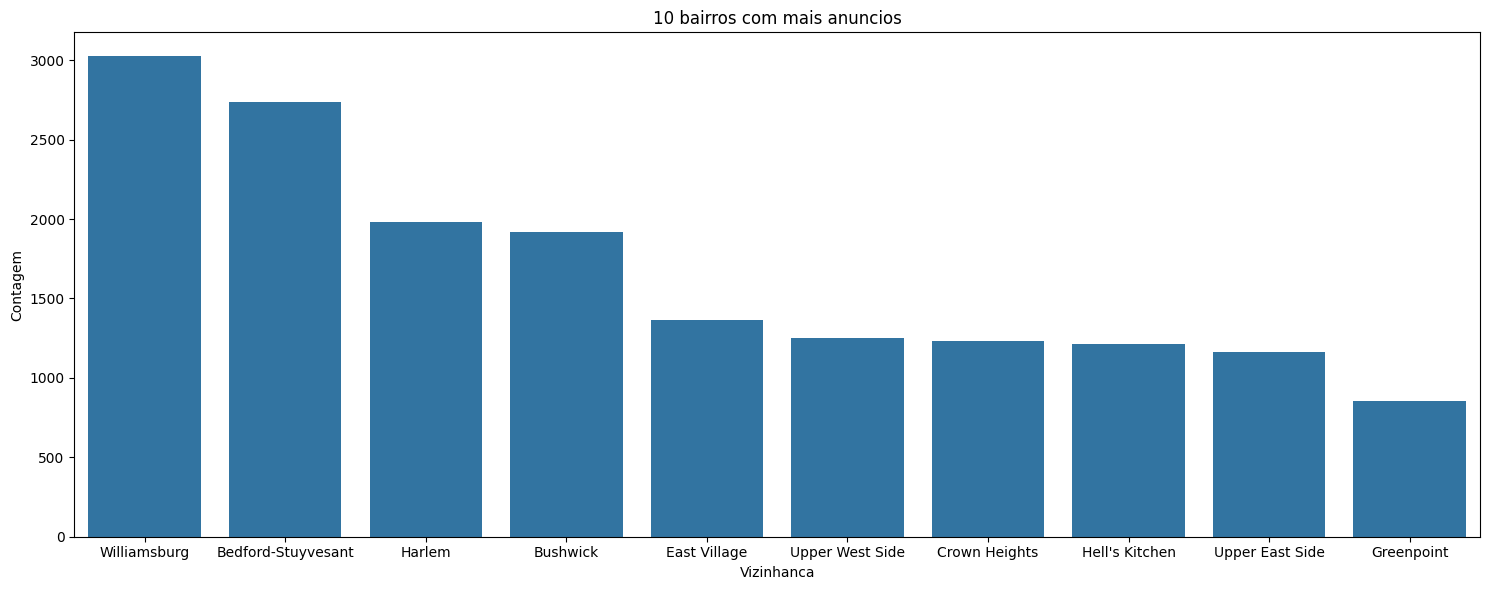

In [9]:
# Calcule os 10 bairros com mais anúncios
bairros_mais_anuncios = df["neighbourhood"].value_counts().head(10)
bairros = bairros_mais_anuncios.reset_index()
bairros.columns = ["neighbourhood", "count"]
# Crie um gráfico de barras para visualizar esses bairros usando `sns.barplot`
plt.figure(figsize=(15, 6))
sns.barplot(data=bairros, x="neighbourhood", y="count")
plt.title("10 bairros com mais anuncios")
plt.ylabel("Contagem")
plt.xlabel("Vizinhanca")
plt.tight_layout()
plt.show()
# Adicione títulos e rótulos aos gráficos, e rotacione os rótulos do eixo X se necessário


### 6.5) Análise Geoespacial dos Anúncios
Visualizar os anúncios em um mapa nos permite identificar clusters geográficos e entender a distribuição espacial dos imóveis.


In [ ]:
# Crie um mapa base de Nova York usando `folium.Map`
nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=12)
# Adicione um `MarkerCluster` ao mapa
market_cluster = folium.plugins.MarkerCluster().add_to(nyc)
# Amostre uma parte do DataFrame (e.g., 5000 pontos) para melhor performance na visualização

amostra = df.sample(n=5000, random_state=42)

# Adicione marcadores ao mapa para cada ponto amostrado, incluindo informações no popup

for _, row in amostra.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=f"""
        Neighbourhood: {row["neighbourhood"]}<br>
        Price: ${row["price"]}<br>
        Type: {row["room_type"]}
        """
    ).add_to(market_cluster)
# Salve o mapa em um arquivo HTML (e.g., "airbnb_nyc_map.html")
nyc.save("airbnb_nyc_map.html")
# (Opcional) Exiba o mapa diretamente no notebook se o ambiente suportar


## 7) Engenharia de Features
A engenharia de features envolve a criação de novas variáveis a partir das existentes para melhorar a capacidade preditiva dos modelos ou para obter novos insights. Aqui, criaremos algumas features simples.


### 7.1) `host_experience_days`
Calcularemos a experiência do anfitrião em dias, baseando-nos na data da última avaliação (`last_review`) e uma data de referência (ou a data da primeira avaliação, se disponível). Isso pode indicar a longevidade e experiência do anfitrião na plataforma.


In [ ]:
# Calcule a data mais recente de `last_review`
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
# Crie a nova feature `host_experience_days` calculando a diferença em dias entre a data mais recente e `last_review`
data_mais_recente = df["last_review"].max()
df["host_experience_days"] = (data_mais_recente - df["last_review"]).dt.days
# Exiba as estatísticas descritivas da nova feature
print(df["host_experience_days"].describe())

count    35103.000000
mean       914.258810
std       1302.376515
min          0.000000
25%         22.000000
50%        190.000000
75%       1153.000000
max       3475.000000
Name: host_experience_days, dtype: float64


### 7.2) `price_per_night_per_review`
Esta feature pode indicar o custo-benefício percebido, relacionando o preço por noite com o número de avaliações. Um valor baixo pode indicar um bom negócio, enquanto um valor alto pode sugerir um preço elevado para poucos reviews.


In [21]:
# Crie a nova feature `price_per_night_per_review`, dividindo `price` por `number_of_reviews`
df["price_per_night_per_review"] = df["price"] / df["number_of_reviews"].replace(0, 1)
# Lembre-se de tratar a divisão por zero (e.g., se `number_of_reviews` for 0, use o próprio `price`)
# Exiba as estatísticas descritivas da nova feature
print(df["price_per_night_per_review"].describe())

count    35103.000000
mean        50.063416
std         63.828276
min          0.000000
25%          5.852003
50%         22.000000
75%         70.000000
max        333.000000
Name: price_per_night_per_review, dtype: float64


## 8) Análise de Correlação
A correlação mede a força e a direção da relação linear entre duas variáveis numéricas. Um mapa de calor (heatmap) da matriz de correlação é uma excelente ferramenta para visualizar essas relações.


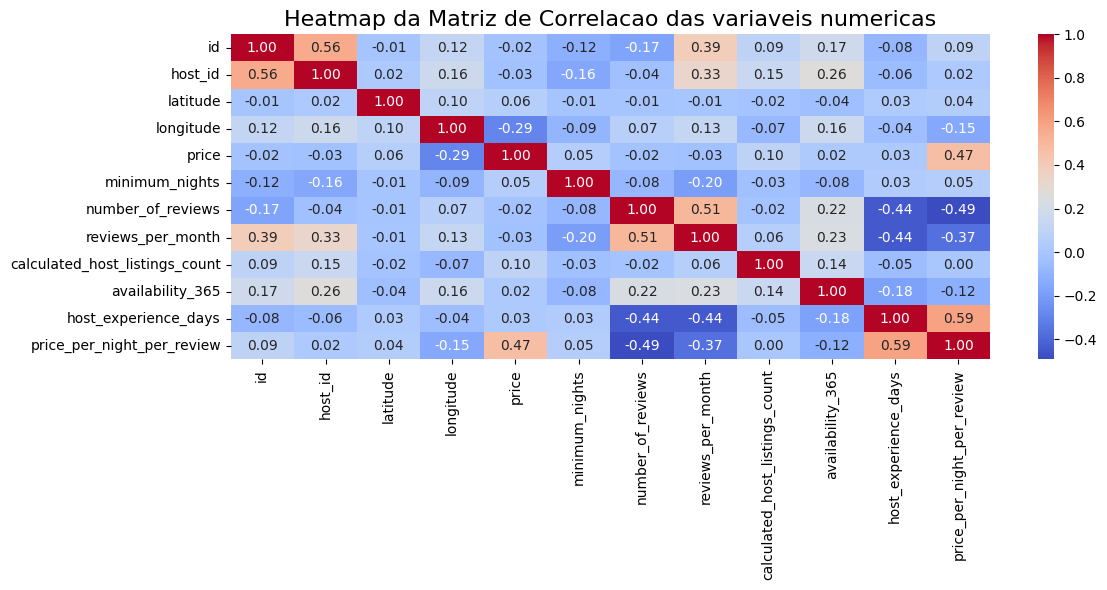

In [22]:
# Selecione apenas as colunas numéricas do DataFrame
# Calcule a matriz de correlação
# Crie um heatmap da matriz de correlação usando `sns.heatmap`
# Adicione anotações e um mapa de cores adequado
# Adicione um título ao gráfico
numericas = df.select_dtypes(include=["int64","float64"])
corr_matrix = numericas.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True
)
plt.title("Heatmap da Matriz de Correlacao das variaveis numericas", fontsize=16)
plt.tight_layout()
plt.show()